In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from scipy.spatial import ConvexHull, QhullError

In [2]:
# Extracting temporal features
def toTime(df):
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df['month'] = df['time'].dt.month
    df['day'] = df['time'].dt.day
    df['hour'] = df['time'].dt.hour
    df['minute'] = df['time'].dt.minute
    df['second'] = df['time'].dt.second
    df['dayofweek'] = df['time'].dt.dayofweek  # Monday=0, Sunday=6
    df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    return df

# Create a DataFrame for submission
def submit(test_ids, ylong, ylat):
    # Create a submission DataFrame
    submission = pd.DataFrame({
        'ID': test_ids,  # Pass the test ID column
        'longitude_predicted': ylong,  # Your predicted longitudes
        'latitude_predicted': ylat    # Your predicted latitudes
    })

    # Ensure the correct column order
    submission = submission[['ID', 'longitude_predicted', 'latitude_predicted']].sort_values(by = 'ID').reset_index(drop=True)

    # Find the next available filename by checking existing files
    i = 1
    while os.path.exists(f'jakobs_results_{i}.csv'):
        i += 1

    # Save to CSV with the next available filename
    filename = f'jakobs_results_{i}.csv'
    submission.to_csv(filename, index=False)
    print(f"Results saved to {filename}")

# Function to split each vessel's data
def time_series_split_by_vessel(df, train_size=0.97):
    train_dfs = []
    val_dfs = []

    # Group by vesselId to split each vessel's data individually
    for vessel_id, vessel_data in df.groupby('vesselId'):
        # Calculate the split index for this vessel
        split_index = int(len(vessel_data) * train_size)

        # Split into training and validation sets for this vessel
        train_dfs.append(vessel_data.iloc[:split_index])
        val_dfs.append(vessel_data.iloc[split_index:])

    # Concatenate all vessel's training and validation data back into a DataFrame
    train_df = pd.concat(train_dfs)
    val_df = pd.concat(val_dfs)

    return train_df, val_df

# Define the Haversine function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Define a function to wrap latitude to the range [-90, 90]
def wrap_latitude(lat):
    if lat > 90:
        return 180 - lat  # Bounce back from the North Pole
    elif lat < -90:
        return -180 - lat  # Bounce back from the South Pole
    return lat

# Define a function to wrap longitude to the range [-180, 180]
def wrap_longitude(lon):
    return ((lon + 180) % 360) - 180  # Wraps around using modulo

def calculate_covered_area(df, lat_col='latitude', long_col='longitude'):
    results = []
    
    # Group by vesselId to calculate the covered area for each vessel
    for vessel_id, vessel_data in df.groupby('vesselId'):
        # Drop any rows with NaN values in the latitude or longitude columns
        vessel_data = vessel_data.dropna(subset=[lat_col, long_col])
        
        # Ensure there are enough unique points to form a hull (at least 3)
        unique_points = vessel_data[[lat_col, long_col]].drop_duplicates()
        if len(unique_points) < 3:
            results.append({'vesselId': vessel_id, 'covered_area': 0})
            continue

        # Convert lat/long to 2D points (in meters) for ConvexHull calculation
        lat_to_m = 111320  # meters per degree latitude
        long_to_m = 40075000 * np.cos(np.radians(vessel_data[lat_col].mean())) / 360  # meters per degree longitude
        
        # Convert latitude and longitude to Cartesian coordinates (in meters)
        points = np.column_stack((unique_points[long_col] * long_to_m, unique_points[lat_col] * lat_to_m))
        
        # Attempt to calculate the convex hull; handle flat cases
        try:
            hull = ConvexHull(points)
            area = hull.volume  # volume returns the area for a 2D hull in scipy
        except QhullError:
            area = 1  # If ConvexHull fails due to flat simplex, set area to 0

        results.append({'vesselId': vessel_id, 'covered_area': area})
    
    # Convert results to DataFrame and return
    return pd.DataFrame(results)

def haversine_distance(lat1, lon1, lat2, lon2):
    # Earth radius in meters
    R = 6371000  

    # Convert latitude and longitude from degrees to radians
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)

    # Haversine formula
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c

    return distance

def average_distance_in_meters(y_true_lat, y_true_long, y_pred_lat, y_pred_long):
    distances = haversine_distance(y_true_lat, y_true_long, y_pred_lat, y_pred_long)
    avg_distance = np.mean(distances)
    return avg_distance

In [3]:
# First we read the necessary csv files. NOTE: Different delimiter for some files.
df_train = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ais_train.csv', delimiter = '|')
df_test = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ais_test.csv')
df_vessels = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/vessels.csv', delimiter = '|')
df_schedules = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/schedules_to_may_2024.csv', delimiter = '|')
df_ports = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ports.csv', delimiter = '|')
# NOTE: Train is sorted by vessel ID and time for model to notice temporal trend.
df_train = df_train.sort_values(by = ['vesselId', 'time'])
df_test = df_test.sort_values(by = ['vesselId', 'time'])

In [4]:
# Extracting temporal features
df_train = toTime(df_train)
df_test = toTime(df_test)

In [5]:
# Calculate means of the columns without outliers
sog_mean = df_train.loc[df_train['sog'] < 30, 'sog'].mean()
cog_mean = df_train.loc[df_train['cog'] < 360, 'cog'].mean()
heading_mean = df_train.loc[df_train['heading'] < 360, 'heading'].mean()

# Cleaning the data. Ensuring all data is within reasonable limits and replacing outliers/erranous data with NaN
df_train['cog'] = df_train['cog'].apply(lambda x: float(x) if float(x) < 360 else cog_mean)
# NOTE: We determine that SOG above 25 knots shall be disregarded.
df_train['sog'] = df_train['sog'].apply(lambda x: float(x) if float(x) < 30 else sog_mean)
df_train['heading'] = df_train['heading'].apply(lambda x: float(x) if float(x) < 360 else heading_mean)
# NOTE: Navstat of 0 and 8 both indicate a moving vessel. We therefore combine these two
df_train['navstat'] = df_train['navstat'].replace(8, 0)

In [6]:
# Create lagging features for latitude, longitude, sog, cog, and navstat
for lag in range(1, 5):  # Adding lag-1, lag-2, and lag-3 features
    df_train[f'latitude_lag{lag}'] = df_train.groupby('vesselId')['latitude'].shift(lag)
    df_train[f'longitude_lag{lag}'] = df_train.groupby('vesselId')['longitude'].shift(lag)
    df_train[f'sog_lag{lag}'] = df_train.groupby('vesselId')['sog'].shift(lag)
    df_train[f'cog_lag{lag}'] = df_train.groupby('vesselId')['cog'].shift(lag)
    df_train[f'heading_lag{lag}'] = df_train.groupby('vesselId')['heading'].shift(lag)
    df_train[f'navstat_lag{lag}'] = df_train.groupby('vesselId')['navstat'].shift(lag)


last_known_lags = df_train.groupby('vesselId').last().reset_index()

# Select only the lagged columns and vesselId for merging with the test set
lagged_columns = [col for col in last_known_lags.columns if 'lag' in col] + ['vesselId']
last_known_lags = last_known_lags[lagged_columns]

df_test = df_test.merge(last_known_lags, on='vesselId', how='left')

# Fill missing values in lagged features with 0, mean, or another reasonable choice
for col in lagged_columns:
    df_test[col] = df_test[col].fillna(0)
    df_train[col] = df_train[col].fillna(0)

In [7]:
# Feature determining the maximum possible travelled distance
# Calculate the time difference in seconds between each timestamp within each vessel's data
df_train['time_diff'] = df_train.groupby('vesselId')['time'].diff().dt.total_seconds().fillna(0)

# Convert `sog` from knots to meters per second and calculate the traveled distance in meters
df_train['expected_distance_m'] = df_train['sog'] * 0.514444 * df_train['time_diff']

# Convert the distance from meters to degrees latitude (approximately constant)
df_train['distance_deg'] = df_train['expected_distance_m'] / 111139

# Calculate the change in latitude (delta_lat) based on `cog`
df_train['delta_lat'] = df_train['distance_deg'] * np.cos(np.radians(df_train['cog']))

# Calculate the change in longitude (delta_long), accounting for the variation with latitude
df_train['delta_long'] = (df_train['distance_deg'] * np.sin(np.radians(df_train['cog']))) / np.cos(np.radians(df_train['latitude']))

# Calculate the expected new position
df_train['expected_lat'] = df_train['latitude'] + df_train['delta_lat']
df_train['expected_long'] = df_train['longitude'] + df_train['delta_long']

# Wrapping
df_train['expected_lat'] = df_train['expected_lat'].apply(wrap_latitude)
df_train['expected_long'] = df_train['expected_long'].apply(wrap_longitude)

In [8]:
# Applying the same to df_test

# Extracting the last known vessel position from training set
last_known_info = df_train.groupby('vesselId').last()[['latitude', 'longitude', 'sog', 'cog', 'time']]

# Merging this with test set
df_test = df_test.merge(last_known_info, on='vesselId', how='left', suffixes=('', '_last'))

# Calculating the time difference between samples (seconds)
df_test['time_diff'] = (pd.to_datetime(df_test['time']) - pd.to_datetime(df_test['time_last'])).dt.total_seconds()

# Converting sog from knots to m/s
df_test['sog_mps'] = df_test['sog'] * 0.514444

# Calculating the travelled distance based on time difference and sog
df_test['distance_traveled_m'] = df_test['sog_mps'] * df_test['time_diff']

# Converting travelled distance to degrees
# Latitude displacement in degrees
df_test['distance_deg'] = df_test['distance_traveled_m'] / 111139

# Calculating change in latitude and longitude
df_test['delta_lat'] = df_test['distance_deg'] * np.cos(np.radians(df_test['cog']))
df_test['delta_long'] = (df_test['distance_deg'] * np.sin(np.radians(df_test['cog']))) / \
                        np.cos(np.radians(df_test['latitude']))

# Calculating the expected latitude and longitude based on information above
df_test['expected_lat'] = df_test['latitude'] + df_test['delta_lat']
df_test['expected_long'] = df_test['longitude'] + df_test['delta_long']

# Wrapping to ensure latitude and longitude stays within their respective limits
df_test['expected_lat'] = df_test['expected_lat'].apply(wrap_latitude)
df_test['expected_long'] = df_test['expected_long'].apply(wrap_longitude)

In [9]:
# Step 1: Calculate covered area for df_train using actual positions
covered_area_df_train = calculate_covered_area(df_train, lat_col='latitude', long_col='longitude')

# Step 2: Get the last known covered area for each vesselId in df_train
# Merge with df_train to align covered_area values, then get the last area for each vesselId
df_train = df_train.merge(covered_area_df_train, on='vesselId', how='left')
last_covered_area = df_train.groupby('vesselId')['covered_area'].last().reset_index()

# Step 3: Merge the last known covered area with df_test
df_test = df_test.merge(last_covered_area, on='vesselId', how='left', suffixes=('', '_last'))


In [10]:
# Calculating the distance between two consecutive data points. Indicating if the vessel is travelling far or not.
df_train['distance_from_last'] = haversine_distance(df_train['latitude'], df_train['longitude'], 
                                                    df_train['latitude_lag1'], df_train['longitude_lag1'])
df_test['distance_from_last'] = haversine_distance(df_test['expected_lat'], df_test['expected_long'], 
                                                   df_test['latitude_lag1'], df_test['longitude_lag1'])

In [11]:
df_train['is_moored'] = df_train['navstat_lag1'].isin([1,8]).astype(int)
df_test['is_moored'] = df_test['navstat_lag1'].isin([1,8]).astype(int)

In [12]:
label_encoder = LabelEncoder()
df_train['vesselId_encoded'] = label_encoder.fit_transform(df_train['vesselId'])
df_test['vesselId_encoded'] = label_encoder.transform(df_test['vesselId'])

**Random Forest Regressor for validation**

In [ ]:
# Implementing a RandomForestRegressor
# First defining training, test sets and target predictors.
features = [
            'expected_lat', 'expected_long',
            'latitude_lag1', 'longitude_lag1'
            ]

print(f"Features: {features}")

train_df, val_df = train_test_split(df_train, test_size=0.2, random_state=42)
X_train = train_df[features].copy()
X_val = val_df[features].copy()

y_train = train_df[['latitude', 'longitude']].copy()
y_val_lat = val_df['latitude'].copy()
y_val_long = val_df['longitude'].copy()

RFR = RandomForestRegressor(n_estimators = 30, n_jobs = -1, random_state = 42)

multi_output_regressor = MultiOutputRegressor(RFR)

multi_output_regressor.fit(X_train, y_train)

y_pred = multi_output_regressor.predict(X_val)

y_pred_lat = y_pred[:, 0]
y_pred_long = y_pred[:, 1]

# Extract feature importances for each target
latitude_importances = multi_output_regressor.estimators_[0].feature_importances_
longitude_importances = multi_output_regressor.estimators_[1].feature_importances_

# Average feature importances across targets for a combined importance
average_importances = np.mean([latitude_importances, longitude_importances], axis=0)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, average_importances, color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Average Feature Importance for Latitude and Longitude Prediction")
plt.show()

mae_lat = mean_absolute_error(y_val_lat, y_pred_lat)
mae_long = mean_absolute_error(y_val_long, y_pred_long)
r2_lat = r2_score(y_val_lat, y_pred_lat)
r2_long = r2_score(y_val_long, y_pred_long)
# Calculate the average distance in meters between predicted and actual positions in the validation set
average_distance = average_distance_in_meters(y_val_lat, y_val_long, y_pred_lat, y_pred_long)

print(f'Latitude: MAE: {mae_lat:.2f}, R^2: {r2_lat:.2f}')
print(f'Longitude: MAE: {mae_long:.2f}, R^2: {r2_long:.2f}')

print(f'Average deviation: {average_distance:.2f} meters')

Features: ['distance_from_last', 'is_moored', 'expected_lat', 'expected_long', 'latitude_lag1', 'longitude_lag1']


KeyboardInterrupt: 

**Random Forest Regressor model for Kaggle**

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 20building tree 2 of 20

building tree 3 of 20
building tree 4 of 20
building tree 5 of 20
building tree 6 of 20
building tree 7 of 20
building tree 8 of 20
building tree 9 of 20
building tree 10 of 20
building tree 11 of 20
building tree 12 of 20
building tree 13 of 20
building tree 14 of 20
building tree 15 of 20
building tree 16 of 20
building tree 17 of 20
building tree 18 of 20
building tree 19 of 20
building tree 20 of 20


[Parallel(n_jobs=-1)]: Done  16 out of  20 | elapsed:   35.5s remaining:    8.9s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:   45.2s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 20building tree 2 of 20

building tree 3 of 20
building tree 4 of 20
building tree 5 of 20
building tree 6 of 20
building tree 7 of 20
building tree 8 of 20
building tree 9 of 20
building tree 10 of 20
building tree 11 of 20
building tree 12 of 20
building tree 13 of 20
building tree 14 of 20
building tree 15 of 20
building tree 16 of 20
building tree 17 of 20
building tree 18 of 20
building tree 19 of 20
building tree 20 of 20


[Parallel(n_jobs=-1)]: Done  16 out of  20 | elapsed:   32.9s remaining:    8.2s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:   44.9s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 out of  20 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 out of  20 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:    0.0s finished


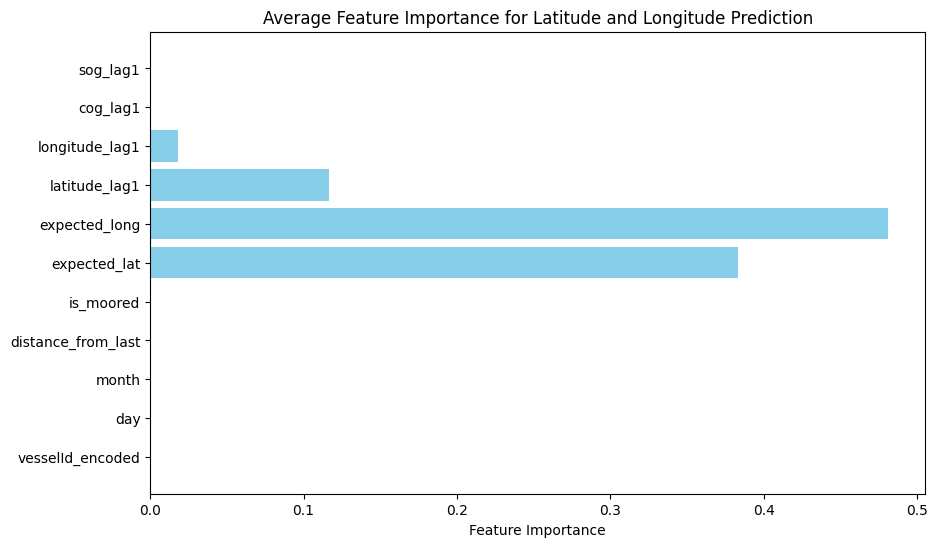

Results saved to jakobs_results_10.csv


In [ ]:
# Implementing a RandomForestRegressor
# First defining training, test sets and target predictors.
features = [
            'expected_lat', 'expected_long',
            'latitude_lag1', 'longitude_lag1'
            ]

X_train = df_train[features].copy()
X_test = df_test[features].copy()

y_train = df_train[['latitude', 'longitude']].copy()

RFR = RandomForestRegressor(n_estimators = 20, n_jobs = -1, random_state = 42, verbose = 2)
multi_output_regressor = MultiOutputRegressor(RFR)

multi_output_regressor.fit(X_train, y_train)

y_pred = multi_output_regressor.predict(X_test)

y_pred_lat = y_pred[:, 0]
y_pred_long = y_pred[:, 1]

# Extract feature importances for each target
latitude_importances = multi_output_regressor.estimators_[0].feature_importances_
longitude_importances = multi_output_regressor.estimators_[1].feature_importances_

# Average feature importances across targets for a combined importance
average_importances = np.mean([latitude_importances, longitude_importances], axis=0)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, average_importances, color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Average Feature Importance for Latitude and Longitude Prediction")
plt.show()

submit(df_test['ID'], y_pred_long, y_pred_lat)